In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl
from scipy.stats import mannwhitneyu

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

PALETTE = {
    "Group Housed": 'steelblue',     
    "Pseudo Control": 'skyblue'}

HUE_ORDER = ["Group Housed", "Pseudo Control"]


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/nearest_neighbour.csv')
df1['condition'] = 'Group Housed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/pseudo-n10/group-housed/nearest_neighbour.csv')
df2['condition'] = 'Pseudo Control'

df = pd.concat([df1, df2], ignore_index=True)


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_23840/646797734.py:26: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[1, 1, 1, 1])


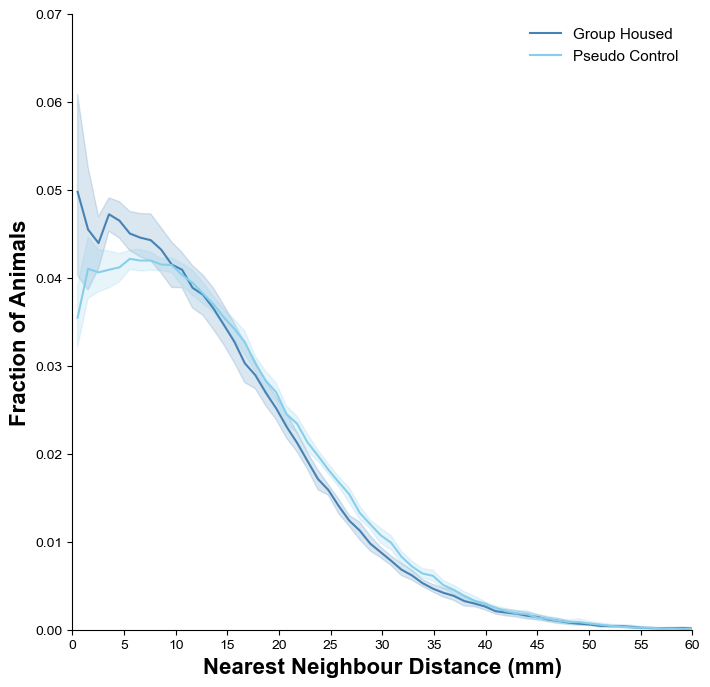

In [8]:
bins = np.linspace(0, 90, 90)  # 0 to 2.5 in 0.1 increments
df['bin'] = pd.cut(df['head_distance'], bins, include_lowest=True)
df['bin_center'] = df['bin'].apply(lambda x: x.mid)


# Count per file-condition-bin
counts = (
    df.groupby(['filename', 'condition', 'bin_center'])
    .size()
    .groupby(['filename', 'condition'], group_keys=False)
    .apply(lambda x: x / x.sum())
    .reset_index(name='density')
)


plt.figure(figsize=(8,8))

ax = sns.lineplot(data=counts, x='bin_center', y='density', hue='condition', errorbar=('ci', 95), palette=PALETTE, hue_order=HUE_ORDER) 
plt.xlabel('Nearest Neighbour Distance (mm)', fontsize=16, fontweight='bold')
plt.ylabel('Fraction of Animals', fontsize=16, fontweight='bold')
sns.despine()
ax.legend(frameon=False, title=None, fontsize=11, loc="upper right")

# plt.title('Nearest Neighour Distance Distriubtion', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[1, 1, 1, 1])

plt.ylim(0, 0.07)
plt.xlim(0, 60)
ax.set_xticks(np.arange(0, 61, 5))


# plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/ghXpseudo/nearest-neighour-distance.pdf', format='pdf', bbox_inches='tight')
plt.show()


Mann–Whitney U = 7.000, p = 1.3149e-03
N files — Group Housed: 10, Pseudo Control: 10
Cliff's delta = -0.860


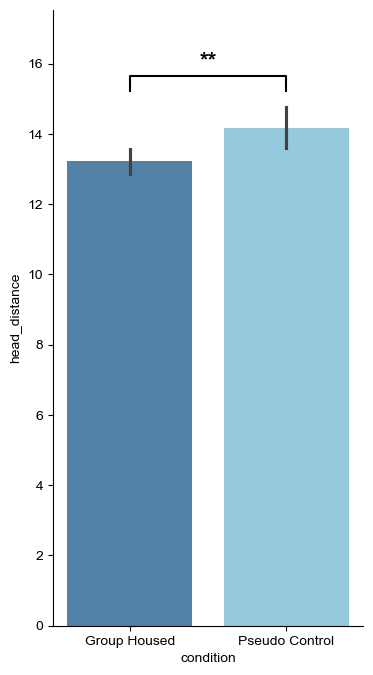

In [9]:
# 1) Mean per track per file
track_means = (
    df.groupby(['filename', 'condition', 'track_id'])['head_distance']
    .mean()
    .reset_index()
)

# 2) Collapse tracks → single value per file
file_means = (
    track_means
    .groupby(['filename', 'condition'])['head_distance']
    .mean()
    .reset_index()
)

# 3) Split conditions
gh = file_means.query("condition == 'Group Housed'")['head_distance']
pc = file_means.query("condition == 'Pseudo Control'")['head_distance']

# 4) Mann–Whitney U test
u, p = mannwhitneyu(gh, pc, alternative='two-sided')

print(f"Mann–Whitney U = {u:.3f}, p = {p:.4e}")
print(f"N files — Group Housed: {len(gh)}, Pseudo Control: {len(pc)}")

def cliffs_delta(x, y):
    nx = len(x)
    ny = len(y)
    greater = sum(xi > yj for xi in x for yj in y)
    less = sum(xi < yj for xi in x for yj in y)
    return (greater - less) / (nx * ny)

delta = cliffs_delta(gh, pc)
print(f"Cliff's delta = {delta:.3f}")


def p_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

plt.figure(figsize=(4,8))
ax = sns.barplot(data=file_means, x='condition', y='head_distance', hue='condition', legend=False,
                 palette=PALETTE, order=HUE_ORDER, hue_order=HUE_ORDER, errorbar=('sd'))

# --- Mann–Whitney significance bracket (sits above the tallest mean + SD bar) ---
bar_tops = file_means.groupby('condition')['head_distance'].agg(lambda v: v.mean() + v.std())
y_max     = bar_tops.max()
h         = y_max * 0.03             # bracket tip height
y_bracket = y_max * 1.06
stars     = p_to_stars(p)

ax.plot([0, 0, 1, 1], [y_bracket - h, y_bracket, y_bracket, y_bracket - h], color='black', linewidth=1.5)
ax.text(0.5, y_bracket + h * 0.3, stars, ha='center', va='bottom',
        fontsize=16 if stars != 'ns' else 12, fontweight='bold')

plt.ylim(0, max(16, y_bracket * 1.12))   # keep 0-16 unless the bracket needs more room
sns.despine()
# plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/ghXpseudo/nearest-neighour-distance-barplot.pdf', format='pdf', bbox_inches='tight')
plt.show()
